# To predict the onset of diabetes in Pima Indians. Logistic Regression Model.
### How to access Google Drive files in Colab and How to handle **csv** files using **pandas**


##<font color='red'>Do this first!!!</font>
1.   Download **diabetes.csv** file from https://www.kaggle.com/uciml/pima-indians-diabetes-database to your Google Drive and remember the location.
2.   <== click on the folder icon
3. Click on the Mount Drive icon. It will take some seconds to mount.
3.   Drill down "**drive**" folder if you can find the diabetes.csv file
4. Change the file path below for the read_csv function. To access your Google Drive, the path must start with "/content/drive/...".



In [ ]:
import pandas as pd
import numpy as np

##<font color='red'>Introduction to Pands</font>



In [ ]:
#diabetes_data = pd.read_csv('/content/drive/MyDrive/DL_data/simple_csv/diabetes.csv') #
diabetes_data = pd.read_csv('DL_data/simple_csv/diabetes.csv') # Local runtime Anaconda home dir is G:\My Drive
print(diabetes_data.shape)
diabetes_data.head() # this will add "Next steps"

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


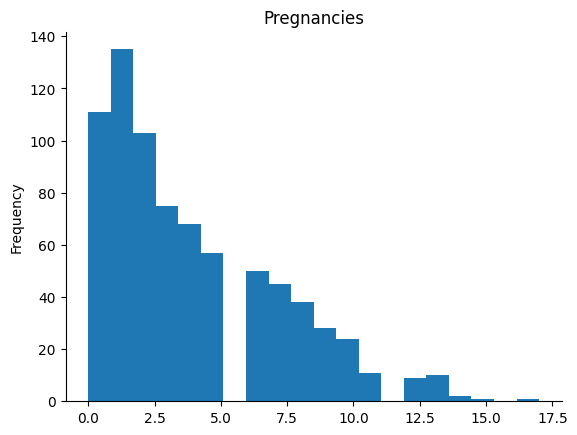

In [ ]:
# @title Pregnancies

from matplotlib import pyplot as plt
diabetes_data['Pregnancies'].plot(kind='hist', bins=20, title='Pregnancies')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# selecting a single column
diabetes_data['Glucose']

0      148
1       85
2      183
3       89
4      137
      ... 
763    101
764    122
765    121
766    126
767     93
Name: Glucose, Length: 768, dtype: int64

In [ ]:
# selecting multiple columns and saving them to another DataFrame
twoCol = diabetes_data[['Glucose','BloodPressure']]
twoCol.info()
twoCol.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Glucose        768 non-null    int64
 1   BloodPressure  768 non-null    int64
dtypes: int64(2)
memory usage: 12.1 KB


,Glucose,BloodPressure
0,148,72
1,85,66
2,183,64
3,89,66
4,137,40


In [ ]:
# drop a column
diabetes_data.drop(columns='Outcome')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [ ]:
# selecting rows
diabetes_data[1:3]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [ ]:
#selecting rows and columns
diabetes_data.loc[1:5, ['Pregnancies','BMI']]

,Pregnancies,BMI
1,1,26.6
2,8,23.3
3,1,28.1
4,0,43.1
5,5,25.6


In [ ]:
# How to convert Pandas' DataFrames to Numpy Arrays?
print(diabetes_data.to_numpy()[:1,0:8]) # 1st row except the label

[[  6.    148.     72.     35.      0.     33.6     0.627  50.   ]]


##<font color='red'>Prepare Training and Test Datasets in Numpy for Keras</font>

In [ ]:
# Use just slicing to prepare train and test datasets
# NumTrain = int(0.8*diabetes_data.shape[0]) # shape[0] has # of rows (samples)
# print(NumTrain)
# X = diabetes_data.to_numpy()[:NumTrain, 0:8]
# y = diabetes_data.to_numpy()[:NumTrain, 8]
# X_test = diabetes_data.to_numpy()[NumTrain:, 0:8]
# y_test = diabetes_data.to_numpy()[NumTrain:, 8]
# print(X.shape)
# print(y.shape)
# print(X_test.shape)
# print(y_test.shape)

from sklearn.model_selection import train_test_split
#X = diabetes_data.iloc[:,0:8] #0-8 columns are dependent variables
X = diabetes_data.to_numpy()[:,0:8]
#y = diabetes_data.iloc[:,8]   #8 column is independent variable (label)
y = diabetes_data.to_numpy()[:,8]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=17)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)
print(y_test)

(576, 8)
(576,)
(192, 8)
(192,)
[0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1.
 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1.
 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0.
 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1.
 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1.]


### We also need Z-score standarization.

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

##<font color='red'>Train and Evaluate test dataset using a Keras model</font>

In [ ]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras import callbacks
model = Sequential()
model.add(Input(shape=(8,)))  # 8 features in the input
for layer in range(2): # experiment for variable layers
  model.add(Dense(100*(3-layer), activation='relu'))
#model.add(Dense(128, activation='tanh'))
#model.add(Dense(1, kernel_initializer='uniform', activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_33"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_80 (Dense)            (None, 300)               2700      
                                                                 
 dense_81 (Dense)            (None, 200)               60200     
                                                                 
 dense_82 (Dense)            (None, 1)                 201       
                                                                 
Total params: 63,101
Trainable params: 63,101
Non-trainable params: 0
_________________________________________________________________


In [ ]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras import callbacks
model = Sequential()
model.add(Input(shape=(13,)))  # 13 features in the input
for layer in range(2): # experiment for variable layers
  model.add(Dense(100*(3-layer), activation='relu'))
#model.add(Dense(128, activation='tanh'))
#model.add(Dense(1, kernel_initializer='uniform', activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mae'])
cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True),
  ]
model.fit(x_train, y_train, epochs=100, batch_size=10, verbose=1,
          validation_data=(x_test, y_test),
          callbacks=cb_list)

Epoch 1/100
58/58 [==============================] - 1s 6ms/step - loss: 0.5512 - mae: 0.3741 - val_loss: 0.4351 - val_mae: 0.2997
Epoch 2/100
58/58 [==============================] - 0s 4ms/step - loss: 0.4752 - mae: 0.3021 - val_loss: 0.4343 - val_mae: 0.3079
Epoch 3/100
58/58 [==============================] - 0s 5ms/step - loss: 0.4638 - mae: 0.3055 - val_loss: 0.4236 - val_mae: 0.2899
Epoch 4/100
58/58 [==============================] - 0s 6ms/step - loss: 0.4517 - mae: 0.2975 - val_loss: 0.4424 - val_mae: 0.2853
Epoch 5/100
58/58 [==============================] - 0s 6ms/step - loss: 0.4428 - mae: 0.2932 - val_loss: 0.4317 - val_mae: 0.2819
Epoch 6/100
58/58 [==============================] - 0s 5ms/step - loss: 0.4386 - mae: 0.2896 - val_loss: 0.4299 - val_mae: 0.2786
Epoch 7/100
58/58 [==============================] - 0s 5ms/step - loss: 0.4223 - mae: 0.2773 - val_loss: 0.4516 - val_mae: 0.2976
Epoch 8/100
58/58 [==============================] - 0s 5ms/step - loss: 0.4188 - m

In [ ]:
model.summary()
score = model.evaluate(x_test, y_test, verbose=0)
print(f'Model loss = {score[0]}   MAE = {score[1]}')

Model: "sequential_33"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_80 (Dense)            (None, 300)               2700      
                                                                 
 dense_81 (Dense)            (None, 200)               60200     
                                                                 
 dense_82 (Dense)            (None, 1)                 201       
                                                                 
Total params: 63,101
Trainable params: 63,101
Non-trainable params: 0
_________________________________________________________________
Model loss = 0.42358192801475525   Accuracy = 0.28986474871635437
